In [1]:
# Importing core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing Preprocessing Tools
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
# Importing Model Selection Utilities
from sklearn.model_selection import train_test_split

In [4]:
# Importing evaluation metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score,roc_curve)

In [5]:
# Configuring General Settings
import warnings
warnings.filterwarnings("ignore")
plt.style.use("default")
%matplotlib inline

# Loading the Dataset

In [6]:
df = pd.read_csv("Telcom-Customer-Churn.csv")

# Data Exploration

In [7]:
#Checking size of Dataframe
df.shape

(7043, 21)

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
#checking for data types and missing values in the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [12]:
# Statistical summary of Categorical columns
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [13]:
# Checking for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [14]:
#checking for missing values
missing = pd.DataFrame({'Missing Count': df.isna().sum(),'Missing %': (df.isna().mean() * 100).round(2)})
print(missing)

                  Missing Count  Missing %
customerID                    0        0.0
gender                        0        0.0
SeniorCitizen                 0        0.0
Partner                       0        0.0
Dependents                    0        0.0
tenure                        0        0.0
PhoneService                  0        0.0
MultipleLines                 0        0.0
InternetService               0        0.0
OnlineSecurity                0        0.0
OnlineBackup                  0        0.0
DeviceProtection              0        0.0
TechSupport                   0        0.0
StreamingTV                   0        0.0
StreamingMovies               0        0.0
Contract                      0        0.0
PaperlessBilling              0        0.0
PaymentMethod                 0        0.0
MonthlyCharges                0        0.0
TotalCharges                  0        0.0
Churn                         0        0.0


# Data Cleaning & EDA

In [16]:
# Dropping columns that do not help prediction(it is a unique identifier)
df.drop("customerID",axis=1,inplace=True)

In [17]:
# Checking remaining columns
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
#Converting TotalCharges to Numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [19]:
#checking missing values & replacing with NAN
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [20]:
# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median())

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
#Target Variable Analysis
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

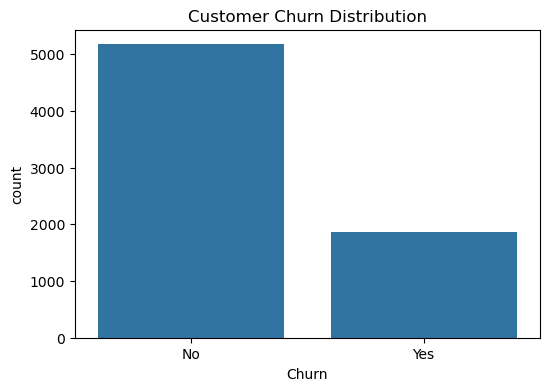

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [24]:
#Numerical Feature Analysis
numerical_features = df.select_dtypes(include=["int64","float64"]).columns
numerical_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

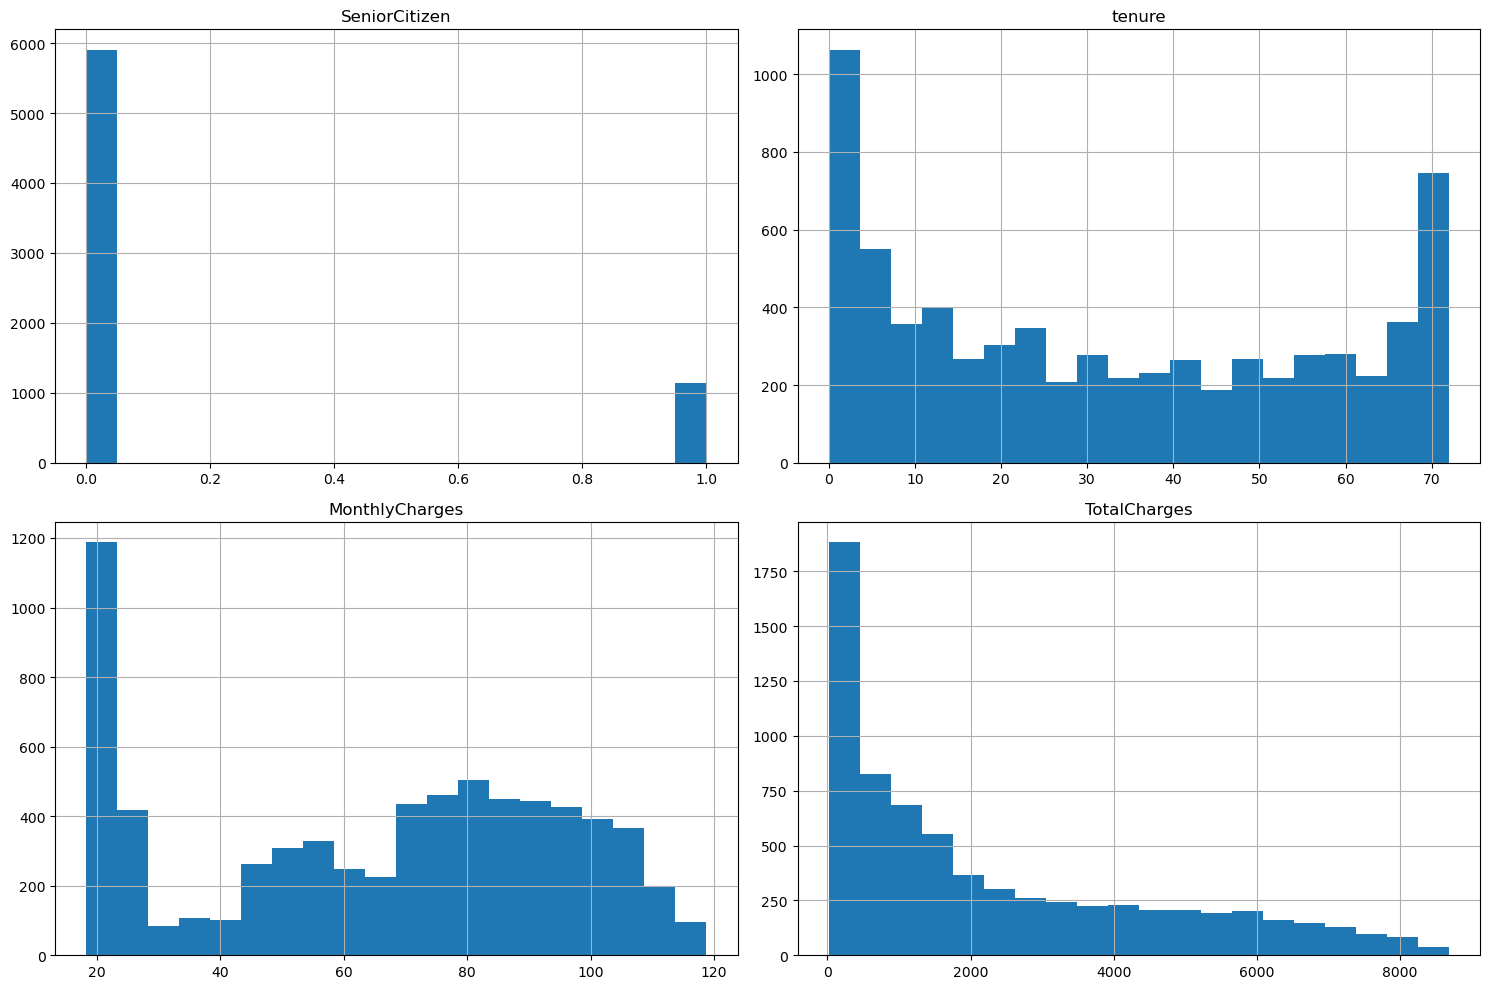

In [25]:
df[numerical_features].hist(figsize=(15,10),bins=20)
plt.tight_layout()
plt.show()

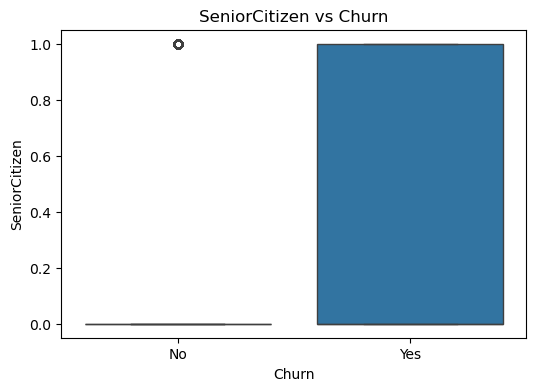

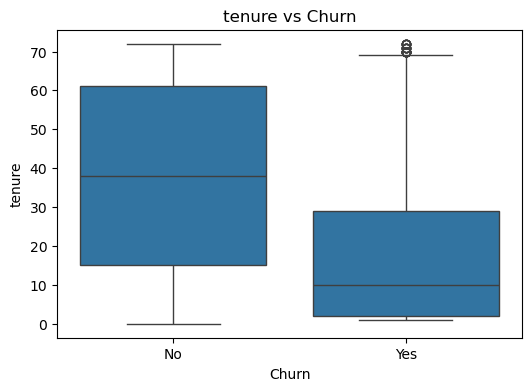

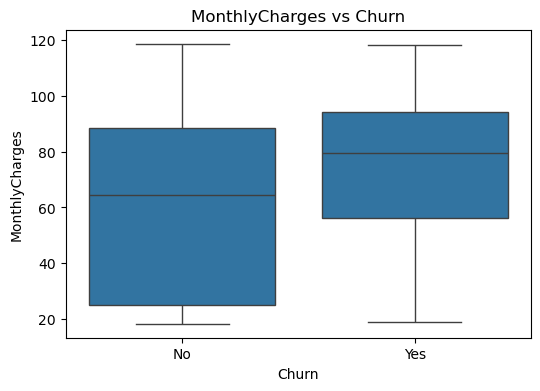

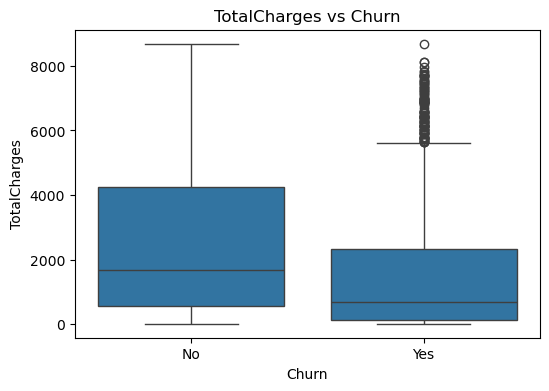

In [26]:
# Churn Relationship with Numerical Features
for col in numerical_features:

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df,x="Churn",y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

In [27]:
# Categorical Feature Analysis
categorical_features = df.select_dtypes(include="object").columns
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

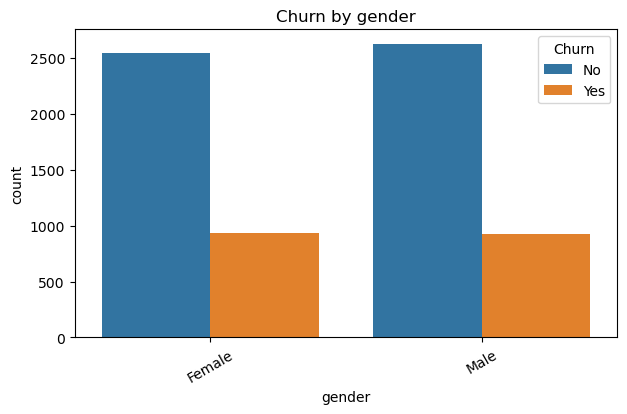

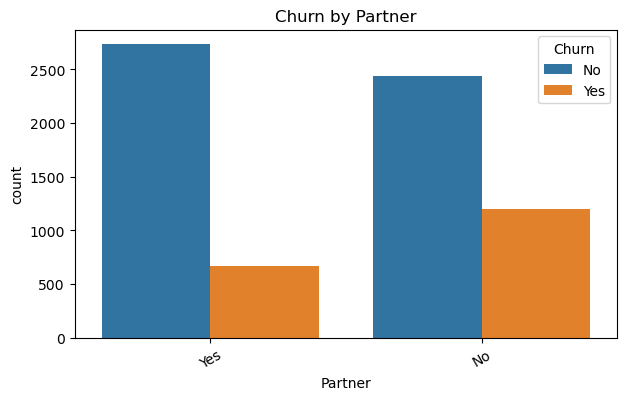

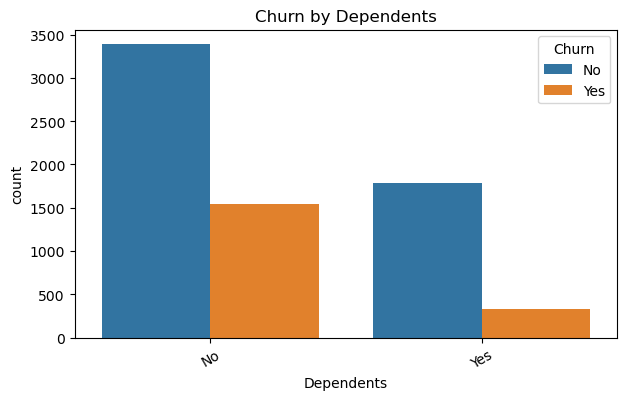

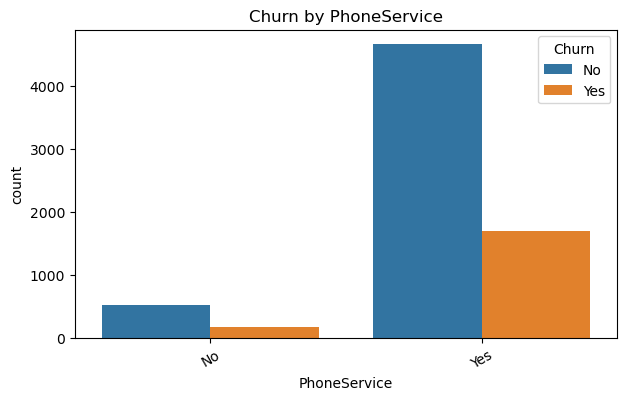

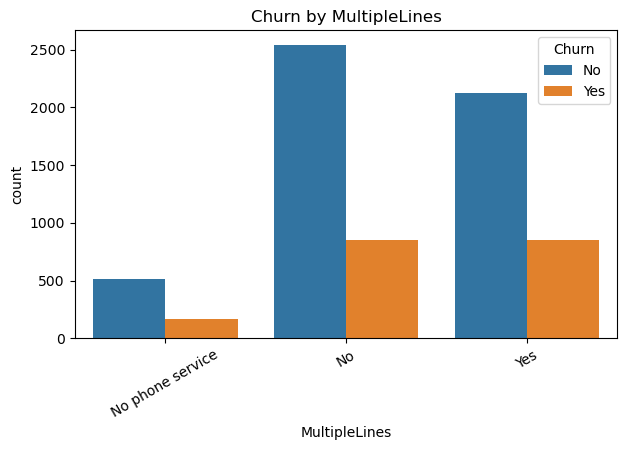

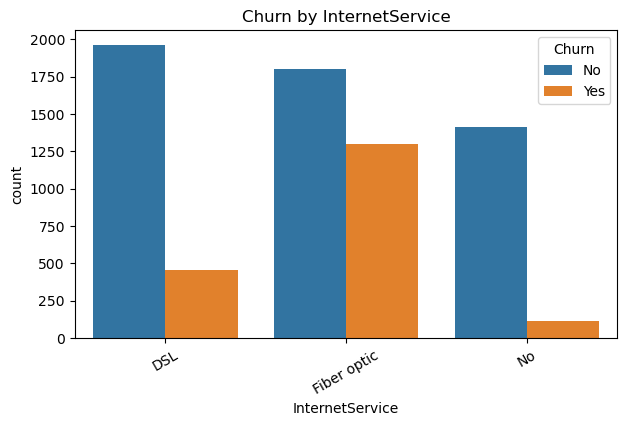

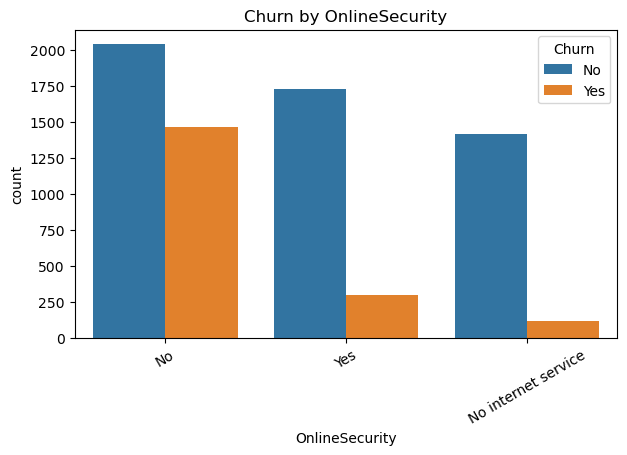

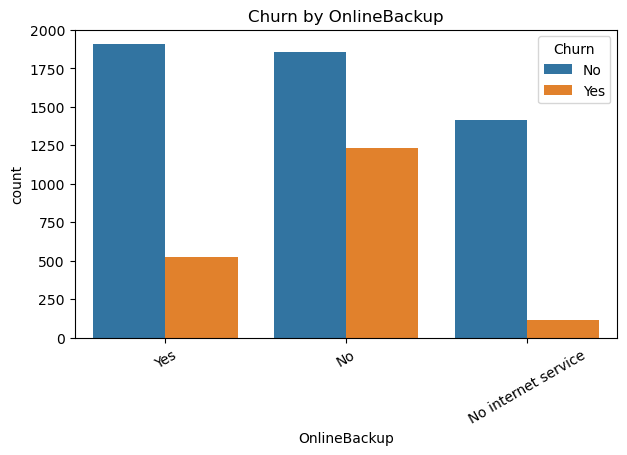

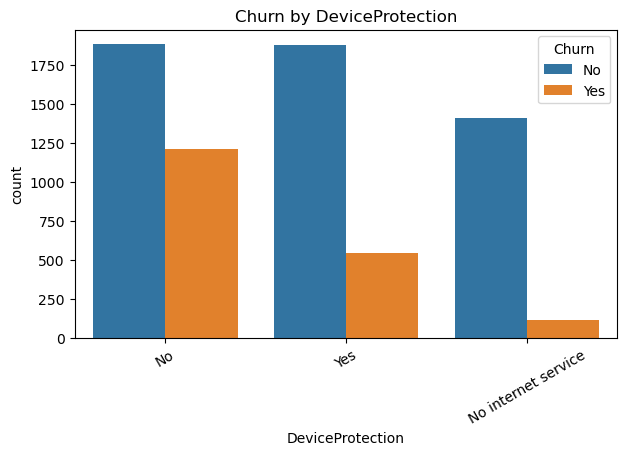

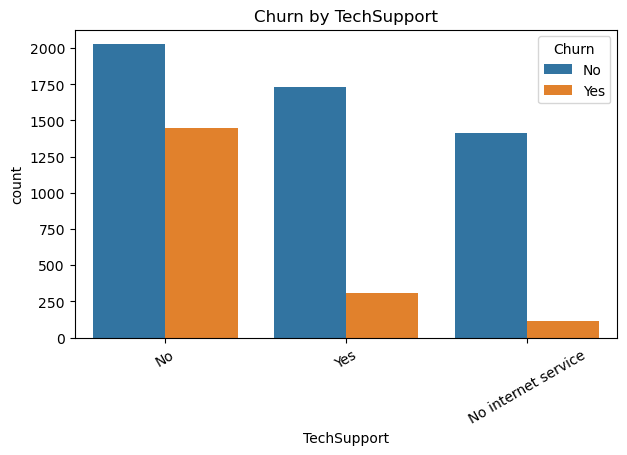

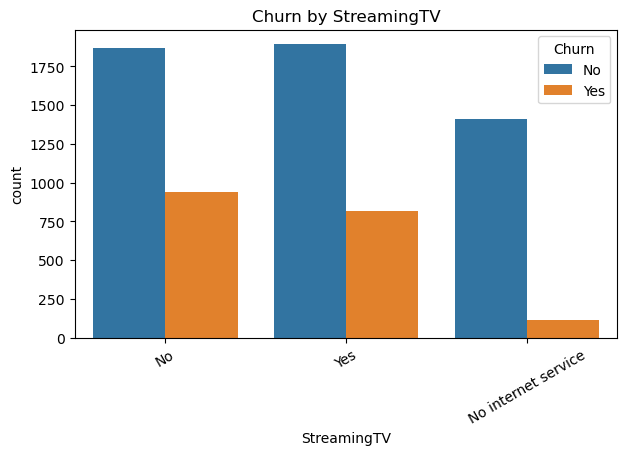

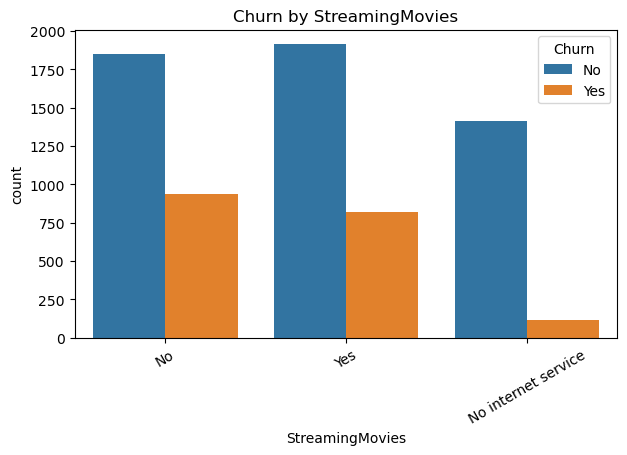

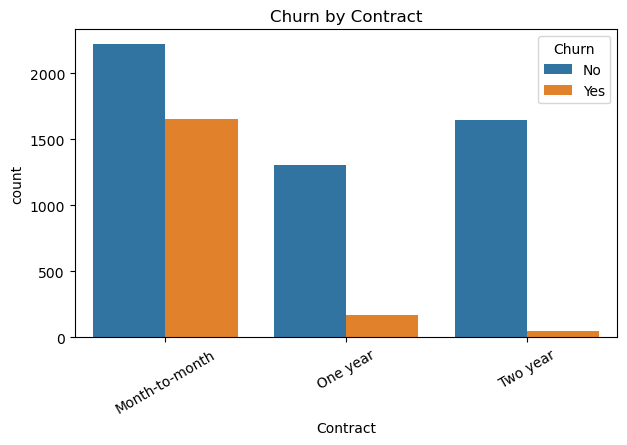

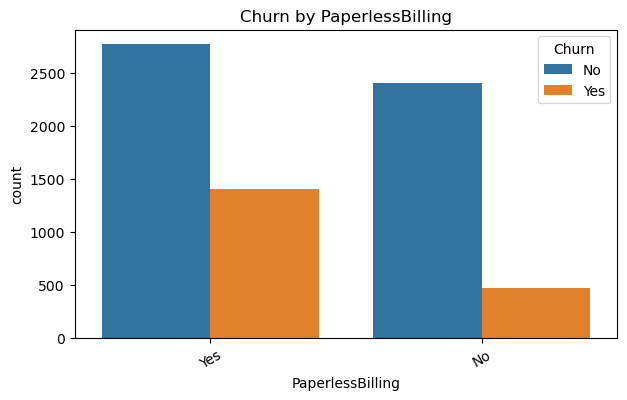

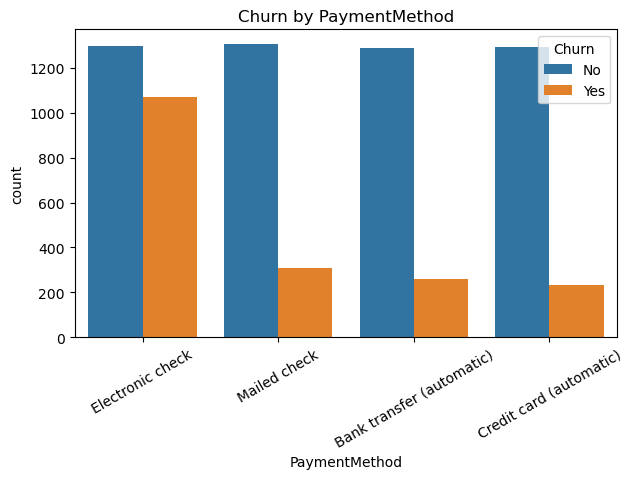

In [28]:
for col in categorical_features:

    if col=="Churn":
        continue
    plt.figure(figsize=(7,4))
    sns.countplot(data=df,x=col,hue="Churn")
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=30)
    plt.show()

In [29]:
# Encoding
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [30]:
categorical_features = df.select_dtypes(include="object").columns
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [31]:
df.isnull().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
DeviceProtection    0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
Churn               0
dtype: int64

In [32]:
# One-hot Encoding
df = pd.get_dummies(df,columns=categorical_features,drop_first=True)

In [33]:
#convert to boolean
df = df.astype(int)

In [34]:
#Feature Scaling
# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [36]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [38]:
# Creating models
models = {"Logistic Regression": LogisticRegression(),"Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),"SVM": SVC(),"KNN": KNeighborsClassifier(),

    "XGBoost": XGBClassifier(use_label_encoder=False,eval_metric="logloss",random_state=42),

    "ANN": MLPClassifier(hidden_layer_sizes=(100,),max_iter=500,random_state=42)}

In [46]:
#Training Models
results = []
for name, model in models.items():
    if name in ["Logistic Regression","SVM","KNN","ANN"]:
        model.fit(X_train_scaled,y_train)
        prediction = model.predict(X_test_scaled)
    else:
        model.fit(X_train,y_train)
        prediction = model.predict(X_test)
    accuracy = accuracy_score(y_test,prediction)
    results.append([name,accuracy])
    print("="*50)
    print(name)
    print(classification_report(y_test,prediction))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78   

In [40]:
# Model Comparison
results = pd.DataFrame(results,columns=["Model","Accuracy"])
results.sort_values(by="Accuracy",ascending=False,inplace=True)
results

,Model,Accuracy
0,Logistic Regression,0.806955
3,SVM,0.792761
2,Random Forest,0.789922
5,XGBoost,0.782115
6,ANN,0.772179
4,KNN,0.747339
1,Decision Tree,0.727466


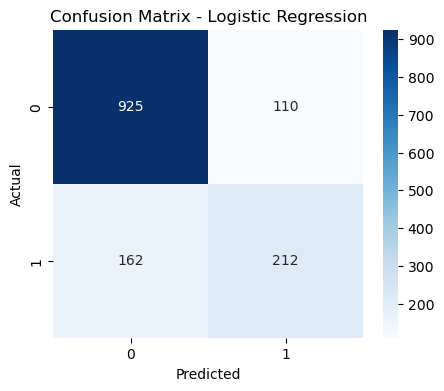

In [41]:
best_model = LogisticRegression(random_state=42)
best_model.fit(X_train_scaled, y_train)
prediction = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, prediction)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [42]:
#model coefficients to know feature influence
importance = pd.DataFrame({"Feature": X.columns,"Coefficient": best_model.coef_[0]})
importance["Absolute Coefficient"] = importance["Coefficient"].abs()
importance = importance.sort_values(by="Absolute Coefficient",ascending=False)
importance.head(15)

,Feature,Coefficient,Absolute Coefficient
1,tenure,-1.230331,1.230331
2,MonthlyCharges,-0.821975,0.821975
10,InternetService_Fiber optic,0.736356,0.736356
25,Contract_Two year,-0.589700,0.589700
3,TotalCharges,0.508344,0.508344
24,Contract_One year,-0.285952,0.285952
23,StreamingMovies_Yes,0.242159,0.242159
21,StreamingTV_Yes,0.241368,0.241368
9,MultipleLines_Yes,0.208239,0.208239
26,PaperlessBilling_Yes,0.182152,0.182152


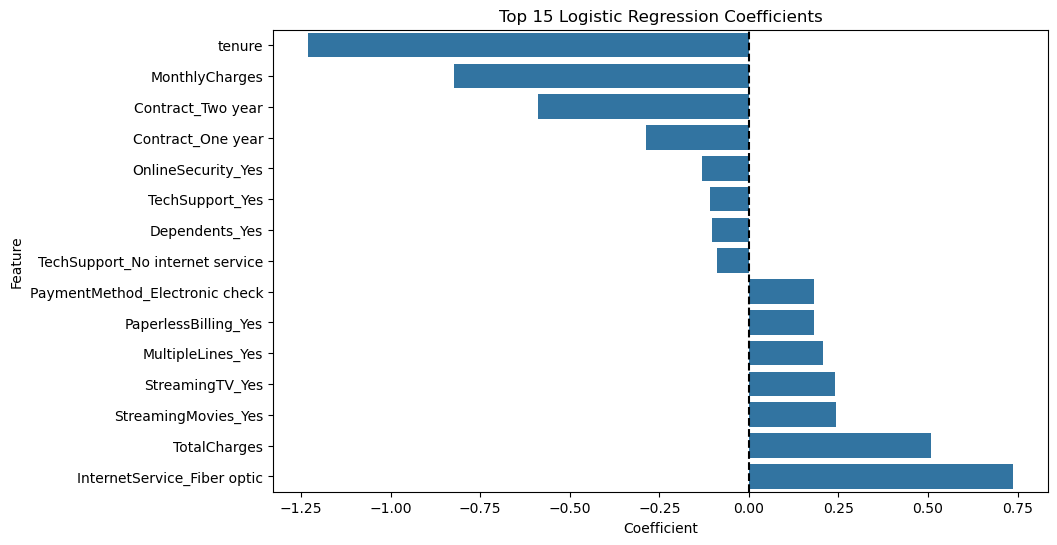

In [43]:
top_features = importance.head(15).sort_values(by="Coefficient")
plt.figure(figsize=(10,6))
sns.barplot(data=top_features,x="Coefficient",y="Feature")
plt.axvline(x=0, color="black", linestyle="--")
plt.title("Top 15 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

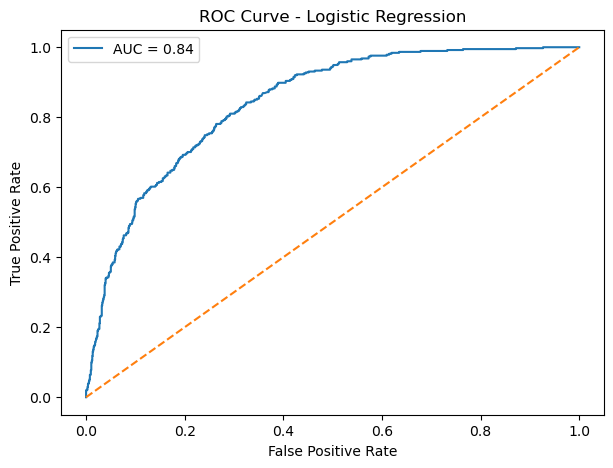

In [45]:
probability = best_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,probability)
fpr,tpr,threshold = roc_curve(y_test,probability)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()